In [ ]:
import pandas as pd
import numpy as np

feature_path = r"C:\Users\User\Desktop\Final Year Project\22b6023 Muizzul\3 Processed Data\FeatureDatasetFixed.xlsx"
cgpa_path = r"C:\Users\User\Desktop\Final Year Project\Data\Transcript_cgpa.xlsx"

feature_df = pd.read_excel(feature_path)
cgpa_df = pd.read_excel(cgpa_path, sheet_name="Y4S2")

#needed columns
cgpa_ref = cgpa_df[["REGNO", "CGPA"]].copy()

# Merge CGPA into marks dataset
merged_df = feature_df.drop(columns=["RISK_BAND_Y4S2"], errors="ignore").merge(
    cgpa_ref,
    on="REGNO",
    how="left"
)

# Map CGPA into 3 classes
def map_risk_3class(cgpa):
    if pd.isna(cgpa):
        return "dropped"
    elif 0 <= cgpa < 2.0:
        return "High Risk"
    elif 2.0 <= cgpa < 3.0:
        return "Moderate Risk"
    elif 3.0 <= cgpa <= 5.0:
        return "Low Risk"
    else:
        return "dropped"

merged_df["RISK_BAND_Y4S2"] = merged_df["CGPA"].apply(map_risk_3class)


merged_df = merged_df.drop(columns=["CGPA"])

# Check counts
print(merged_df["RISK_BAND_Y4S2"].value_counts(dropna=False))

output_path = r"C:\Users\User\Desktop\Final Year Project\22b6023 Muizzul\3 Processed Data\FeatureDatasetFixed_updated.xlsx"
merged_df.to_excel(output_path, index=False)

print(f"Updated file saved to: {output_path}")


RISK_BAND_Y4S2
Low Risk         394
Moderate Risk    148
dropped           61
High Risk         14
Name: count, dtype: int64
Updated file saved to: C:\Users\User\Desktop\Final Year Project\22b6023 Muizzul\3 Processed Data\FeatureDatasetFixed_updated.xlsx


In [ ]:
import pandas as pd
import numpy as np

target_file = r"C:\Users\User\Desktop\Final Year Project\22b6023 Muizzul\3 Processed Data\FeatureDatasetFixed.xlsx"
reference_file = r"C:\Users\User\Desktop\Final Year Project\Data\Transcript_cgpa.xlsx"
output_file = r"C:\Users\User\Desktop\Final Year Project\22b6023 Muizzul\3 Processed Data\FeatureDatasetFixed_allSheets_updated.xlsx"

# Sheets to update
sheet_names = ["Y1S1", "Y1S2", "Y2S1", "Y2S2", "Y3S1", "Y3S2", "Y4S1", "Y4S2"]

def map_risk_3class(cgpa):
    if pd.isna(cgpa):
        return "dropped"
    elif 0 <= cgpa < 2.0:
        return "High Risk"
    elif 2.0 <= cgpa < 3.0:
        return "Moderate Risk"
    elif 3.0 <= cgpa <= 5.0:
        return "Low Risk"
    else:
        return "dropped"

target_sheets = pd.read_excel(target_file, sheet_name=None)
reference_sheets = pd.read_excel(reference_file, sheet_name=None)

updated_sheets = {}

for sheet in sheet_names:
    print(f"\nProcessing sheet: {sheet}")

    # Check sheet exists in both files
    if sheet not in target_sheets:
        print(f"  - Skipped: {sheet} not found in target workbook")
        continue
    if sheet not in reference_sheets:
        print(f"  - Skipped: {sheet} not found in reference workbook")
        continue

    target_df = target_sheets[sheet].copy()
    ref_df = reference_sheets[sheet].copy()

    # Check required columns
    if "REGNO" not in target_df.columns:
        print(f"  - Skipped: REGNO not found in target sheet {sheet}")
        updated_sheets[sheet] = target_df
        continue
    if "REGNO" not in ref_df.columns or "CGPA" not in ref_df.columns:
        print(f"  - Skipped: REGNO and/or CGPA not found in reference sheet {sheet}")
        updated_sheets[sheet] = target_df
        continue

    # Keep only REGNO + CGPA 
    ref_small = ref_df[["REGNO", "CGPA"]].copy()

    # Merge only by matching REGNO
    merged = target_df.drop(columns=["RISK_BAND_Y4S2"], errors="ignore").merge(
        ref_small,
        on="REGNO",
        how="left"
    )

    # Create risk band
    merged["RISK_BAND_Y4S2"] = merged["CGPA"].apply(map_risk_3class)


    merged = merged.drop(columns=["CGPA"])

    # Save updated sheet
    updated_sheets[sheet] = merged

    # Print counts
    print(merged["RISK_BAND_Y4S2"].value_counts(dropna=False))

for sheet_name, df in target_sheets.items():
    if sheet_name not in updated_sheets:
        updated_sheets[sheet_name] = df.copy()


with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    for sheet_name, df in updated_sheets.items():
        df.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"\nDone. Updated workbook saved to:\n{output_file}")


Processing sheet: Y1S1
RISK_BAND_Y4S2
Low Risk         424
Moderate Risk    178
High Risk         15
Name: count, dtype: int64

Processing sheet: Y1S2
RISK_BAND_Y4S2
Low Risk         555
Moderate Risk    250
High Risk         36
Name: count, dtype: int64

Processing sheet: Y2S1
RISK_BAND_Y4S2
Low Risk         562
Moderate Risk    249
High Risk         24
dropped            1
Name: count, dtype: int64

Processing sheet: Y2S2
RISK_BAND_Y4S2
Low Risk         549
Moderate Risk    249
High Risk         29
dropped            1
Name: count, dtype: int64

Processing sheet: Y3S1
RISK_BAND_Y4S2
Low Risk         532
Moderate Risk    263
High Risk         24
Name: count, dtype: int64

Processing sheet: Y3S2
RISK_BAND_Y4S2
Low Risk         530
Moderate Risk    252
High Risk         20
Name: count, dtype: int64

Processing sheet: Y4S1
RISK_BAND_Y4S2
Low Risk         484
Moderate Risk    242
High Risk         20
Name: count, dtype: int64

Processing sheet: Y4S2
RISK_BAND_Y4S2
Low Risk         491
Mo

In [9]:
import pandas as pd

file_path = r"C:\Users\User\Desktop\Final Year Project\22b6023 Muizzul\3 Processed Data\FeatureDatasetFixed_allSheets_updated.xlsx"
sheet_names = ["Y1S1", "Y1S2", "Y2S1", "Y2S2", "Y3S1", "Y3S2", "Y4S1", "Y4S2"]

all_sheets = pd.read_excel(file_path, sheet_name=None)

for sheet in sheet_names:
    df = all_sheets[sheet].copy()
    print(f"\n--- {sheet} ---")
    print(df["RISK_BAND"].dropna().astype(str).map(repr).unique()[:20])


--- Y1S1 ---
["'Moderate Risk'" "'Low Risk'" "'High Risk'"]

--- Y1S2 ---
["'Moderate Risk'" "'Low Risk'" "'High Risk'"]

--- Y2S1 ---
["'Moderate Risk'" "'Low Risk'" "'High Risk'" "'dropped'"]

--- Y2S2 ---
["'Moderate Risk'" "'Low Risk'" "'High Risk'" "'dropped'"]

--- Y3S1 ---
["'Moderate Risk'" "'Low Risk'" "'High Risk'"]

--- Y3S2 ---
["'Moderate Risk'" "'Low Risk'" "'High Risk'"]

--- Y4S1 ---
["'Moderate Risk'" "'Low Risk'" "'High Risk'"]

--- Y4S2 ---
["'Low Risk'" "'Moderate Risk'" "'High Risk'"]


In [10]:
import pandas as pd

file_path = r"C:\Users\User\Desktop\Final Year Project\22b6023 Muizzul\3 Processed Data\FeatureDatasetFixed_allSheets_updated.xlsx"
sheet_names = ["Y1S1", "Y1S2", "Y2S1", "Y2S2", "Y3S1", "Y3S2", "Y4S1", "Y4S2"]

all_sheets = pd.read_excel(file_path, sheet_name=None)

summary = []

for sheet in sheet_names:
    df = all_sheets[sheet].copy()

    counts = df["RISK_BAND"].value_counts(dropna=False)

    summary.append({
        "Sheet": sheet,
        "High Risk (0-<2.0)": counts.get("High Risk", 0),
        "Moderate Risk (2.0-<3.0)": counts.get("Moderate Risk", 0),
        "Low Risk (3.0-5.0)": counts.get("Low Risk", 0),
        "dropped": counts.get("dropped", 0)
    })

summary_df = pd.DataFrame(summary)
print(summary_df)

  Sheet  High Risk (0-<2.0)  Moderate Risk (2.0-<3.0)  Low Risk (3.0-5.0)  \
0  Y1S1                  15                       178                 424   
1  Y1S2                  36                       250                 555   
2  Y2S1                  24                       249                 562   
3  Y2S2                  29                       249                 549   
4  Y3S1                  24                       263                 532   
5  Y3S2                  20                       252                 530   
6  Y4S1                  20                       242                 484   
7  Y4S2                  21                       241                 491   

   dropped  
0        0  
1        0  
2        1  
3        1  
4        0  
5        0  
6        0  
7        0  


In [13]:
import pandas as pd

file_path = r"C:\Users\User\Desktop\Final Year Project\Data\Transcript_cgpa.xlsx"
sheet_names = ["Y1S1", "Y1S2", "Y2S1", "Y2S2", "Y3S1", "Y3S2", "Y4S1", "Y4S2"]

summary = []

for sheet in sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet).copy()

    def map_adjusted_risk(cgpa):
        if pd.isna(cgpa):
            return "dropped"
        elif 0 <= cgpa < 2.7:
            return "High Risk"
        elif 2.7 <= cgpa < 3.3:
            return "Moderate Risk"
        elif 3.0 <= cgpa <= 5.0:
            return "Low Risk"
        else:
            return "dropped"

    df["RISK_BAND_ADJUSTED"] = df["CGPA"].apply(map_adjusted_risk)

    counts = df["RISK_BAND_ADJUSTED"].value_counts().reindex(
        ["High Risk", "Moderate Risk", "Low Risk", "dropped"],
        fill_value=0
    )

    summary.append({
        "Sheet": sheet,
        "High Risk (0-<2.7)": counts["High Risk"],
        "Moderate Risk (2.7-<3.3)": counts["Moderate Risk"],
        "Low Risk (3.3-5.0)": counts["Low Risk"],
        "dropped": counts["dropped"]
    })

summary_df = pd.DataFrame(summary)
print(summary_df)

  Sheet  High Risk (0-<2.7)  Moderate Risk (2.7-<3.3)  Low Risk (3.3-5.0)  \
0  Y1S1                 106                       224                 287   
1  Y1S2                 165                       327                 355   
2  Y2S1                 146                       337                 356   
3  Y2S2                 152                       320                 363   
4  Y3S1                 163                       323                 347   
5  Y3S2                 154                       319                 350   
6  Y4S1                 146                       304                 327   
7  Y4S2                 140                       295                 336   

   dropped  
0        0  
1        0  
2        1  
3        1  
4        1  
5        0  
6        0  
7        0  


In [ ]:
import pandas as pd
import numpy as np


target_file = r"C:\Users\User\Desktop\Final Year Project\22b6023 Muizzul\3 Processed Data\FeatureDatasetFixed_allSheets_updated.xlsx"
reference_file = r"C:\Users\User\Desktop\Final Year Project\Data\Transcript_cgpa.xlsx"
output_file = r"C:\Users\User\Desktop\Final Year Project\22b6023 Muizzul\3 Processed Data\FeatureDatasetFixed_allSheets_updated_balanced.xlsx"


sheet_names = ["Y1S1", "Y1S2", "Y2S1", "Y2S2", "Y3S1", "Y3S2", "Y4S1", "Y4S2"]

def map_risk_band(cgpa):
    if pd.isna(cgpa):
        return "dropped"
    elif 0 <= cgpa < 2.7:
        return "High Risk"
    elif 2.7 <= cgpa < 3.3:
        return "Moderate Risk"
    elif 3.3 <= cgpa <= 5.0:
        return "Low Risk"
    else:
        return "dropped"


target_sheets = pd.read_excel(target_file, sheet_name=None)
reference_sheets = pd.read_excel(reference_file, sheet_name=None)

updated_sheets = {}

for sheet in target_sheets:
    df_target = target_sheets[sheet].copy()


    if sheet in sheet_names and sheet in reference_sheets:
        df_ref = reference_sheets[sheet].copy()

        # Check required columns
        if "REGNO" in df_target.columns and "REGNO" in df_ref.columns and "CGPA" in df_ref.columns:
            ref_small = df_ref[["REGNO", "CGPA"]].copy()

            # Drop old risk band first,
            df_target = df_target.drop(columns=["RISK_BAND"], errors="ignore")

            # Merge CGPA from matching sheet by REGNO
            merged = df_target.merge(ref_small, on="REGNO", how="left")

            # Create new risk band  adjusted thresholds
            merged["RISK_BAND"] = merged["CGPA"].apply(map_risk_band)

     
            merged = merged.drop(columns=["CGPA"], errors="ignore")

            updated_sheets[sheet] = merged

            # Print counts 
            counts = merged["RISK_BAND"].value_counts().reindex(
                ["High Risk", "Moderate Risk", "Low Risk", "dropped"],
                fill_value=0
            )
            print(f"\n--- {sheet} ---")
            print(counts)
        else:
            print(f"\n--- {sheet} skipped: missing REGNO or CGPA column ---")
            updated_sheets[sheet] = df_target
    else:
      
        updated_sheets[sheet] = df_target


with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    for sheet, df in updated_sheets.items():
        df.to_excel(writer, sheet_name=sheet, index=False)

print(f"\nDone. Updated workbook saved to:\n{output_file}")


--- Y1S1 ---
RISK_BAND
High Risk        106
Moderate Risk    224
Low Risk         287
dropped            0
Name: count, dtype: int64

--- Y1S2 ---
RISK_BAND
High Risk        160
Moderate Risk    327
Low Risk         354
dropped            0
Name: count, dtype: int64

--- Y2S1 ---
RISK_BAND
High Risk        143
Moderate Risk    336
Low Risk         356
dropped            1
Name: count, dtype: int64

--- Y2S2 ---
RISK_BAND
High Risk        146
Moderate Risk    319
Low Risk         362
dropped            1
Name: count, dtype: int64

--- Y3S1 ---
RISK_BAND
High Risk        153
Moderate Risk    322
Low Risk         344
dropped            0
Name: count, dtype: int64

--- Y3S2 ---
RISK_BAND
High Risk        148
Moderate Risk    311
Low Risk         343
dropped            0
Name: count, dtype: int64

--- Y4S1 ---
RISK_BAND
High Risk        141
Moderate Risk    291
Low Risk         314
dropped            0
Name: count, dtype: int64

--- Y4S2 ---
RISK_BAND
High Risk        137
Moderate Risk    

In [2]:
import pandas as pd
df = pd.read_excel(
    r"C:\Users\User\Desktop\Final Year Project\22b6023 Muizzul\3 Processed Data\MARKS GPA.xlsx",
    sheet_name="Y4S2"
)
print(df["RISK_BAND_Y4S2"].value_counts())

RISK_BAND_Y4S2
Low Risk         329
Moderate Risk    287
High Risk        137
Name: count, dtype: int64


In [ ]:
#add target for Y4S2 only, then copy to all sheets
import pandas as pd

target_file = r"C:\Users\User\Desktop\Final Year Project\22b6023 Muizzul\3 Processed Data\FeatureDatasetFixed_allSheets_updated.xlsx"
reference_file = r"C:\Users\User\Desktop\Final Year Project\Data\Transcript_cgpa.xlsx"
output_file = r"C:\Users\User\Desktop\Final Year Project\22b6023 Muizzul\3 Processed Data\FeatureDatasetFixed_allSheets_Y4S2target_updated.xlsx"

sheet_names = ["Y1S1", "Y1S2", "Y2S1", "Y2S2", "Y3S1", "Y3S2", "Y4S1", "Y4S2"]

def map_final_risk(cgpa):
    if pd.isna(cgpa):
        return "dropped"
    elif 0 <= cgpa < 2.7:
        return "High Risk"
    elif 2.7 <= cgpa < 3.3:
        return "Moderate Risk"
    elif 3.3 <= cgpa <= 5.0:
        return "Low Risk"
    else:
        return "dropped"


target_sheets = pd.read_excel(target_file, sheet_name=None)

# Read Y4S2 only 
y4s2_ref = pd.read_excel(reference_file, sheet_name="Y4S2")

# Build final target table from Y4S2
y4s2_target = y4s2_ref[["REGNO", "CGPA"]].copy()
y4s2_target["RISK_BAND_Y4S2"] = y4s2_target["CGPA"].apply(map_final_risk)
y4s2_target = y4s2_target[["REGNO", "RISK_BAND_Y4S2"]]

updated_sheets = {}

for sheet in target_sheets:
    df = target_sheets[sheet].copy()

    if sheet in sheet_names:
        if "REGNO" not in df.columns:
            print(f"{sheet}: REGNO not found, skipped")
            updated_sheets[sheet] = df
            continue

        # Remove old final target column 
        df = df.drop(columns=["RISK_BAND_Y4S2"], errors="ignore")

        #keep all students in current sheet
        merged = df.merge(y4s2_target, on="REGNO", how="left")

        # If not found in Y4S2, mark as dropped
        merged["RISK_BAND_Y4S2"] = merged["RISK_BAND_Y4S2"].fillna("dropped")

        updated_sheets[sheet] = merged

        counts = merged["RISK_BAND_Y4S2"].value_counts().reindex(
            ["High Risk", "Moderate Risk", "Low Risk", "dropped"],
            fill_value=0
        )

        print(f"\n--- {sheet} ---")
        print(counts)

    else:
        updated_sheets[sheet] = df

# Save all sheets
with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    for sheet, df in updated_sheets.items():
        df.to_excel(writer, sheet_name=sheet, index=False)

print(f"\nDone. Saved to:\n{output_file}")


--- Y1S1 ---
RISK_BAND_Y4S2
High Risk         78
Moderate Risk    199
Low Risk         279
dropped           61
Name: count, dtype: int64

--- Y1S2 ---
RISK_BAND_Y4S2
High Risk        140
Moderate Risk    295
Low Risk         335
dropped           71
Name: count, dtype: int64

--- Y2S1 ---
RISK_BAND_Y4S2
High Risk        139
Moderate Risk    295
Low Risk         336
dropped           66
Name: count, dtype: int64

--- Y2S2 ---
RISK_BAND_Y4S2
High Risk        140
Moderate Risk    293
Low Risk         335
dropped           60
Name: count, dtype: int64

--- Y3S1 ---
RISK_BAND_Y4S2
High Risk        137
Moderate Risk    292
Low Risk         335
dropped           55
Name: count, dtype: int64

--- Y3S2 ---
RISK_BAND_Y4S2
High Risk        136
Moderate Risk    288
Low Risk         331
dropped           47
Name: count, dtype: int64

--- Y4S1 ---
RISK_BAND_Y4S2
High Risk        135
Moderate Risk    282
Low Risk         324
dropped            5
Name: count, dtype: int64

--- Y4S2 ---
RISK_BAND_Y4S

In [ ]:
import pandas as pd
import numpy as np
from pycaret.classification import setup, compare_models, predict_model, pull, models


file_path = r"C:\Users\User\Desktop\Final Year Project\22b6023 Muizzul\3 Processed Data\FeatureDatasetFixed_allSheets_Y4S2target_updated.xlsx"
output_summary = r"C:\Users\User\Desktop\Final Year Project\22b6023 Muizzul\3 Processed Data\best_model_summary_by_sheet.xlsx"

sheet_names = ["Y1S1", "Y1S2", "Y2S1", "Y2S2", "Y3S1", "Y3S2", "Y4S1", "Y4S2"]
target_col = "RISK_BAND_Y4S2"

# Columns to exclude from predictors
drop_cols_base = [
    "REGNO",
    "checkpoint_id",
    "checkpoint",
    "RISK_BAND",
    "RISK_BAND_Y4S2"
]


requested_models = [
    "lightgbm",
    "et",
    "rf",
    "gbc",
    "lr",
    "ada",
    "dt",
    "knn",
    "svm",
    "rbfsvm",
    "mlp"
]

summary_rows = []

# LOOP THROUGH SHEETS
for sheet_name in sheet_names:
    print("\n" + "=" * 80)
    print(f"PROCESSING SHEET: {sheet_name}")
    print("=" * 80)

    # Load sheet
    df = pd.read_excel(file_path, sheet_name=sheet_name)

    # Keep only valid 3 class target rows
    df_model = df[
        df[target_col].notna() &
        (df[target_col] != "dropped")
    ].copy()

    # Clean target text jic
    df_model[target_col] = (
        df_model[target_col]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

    # Print class distribution
    class_counts = df_model[target_col].value_counts().reindex(
        ["High Risk", "Moderate Risk", "Low Risk"],
        fill_value=0
    )

    print("\nUsable rows:", len(df_model))
    print("Class distribution:")
    print(class_counts)


    if len(df_model) < 30:
        print("Skipped: too few usable rows.")
        summary_rows.append({
            "Sheet": sheet_name,
            "Usable Rows": len(df_model),
            "High Risk": class_counts["High Risk"],
            "Moderate Risk": class_counts["Moderate Risk"],
            "Low Risk": class_counts["Low Risk"],
            "Best Model": "Skipped",
            "CV F1": np.nan,
            "Holdout F1": np.nan,
            "Holdout Accuracy": np.nan
        })
        continue

    # Remove nonfeature columns
    feature_drop_cols = [c for c in drop_cols_base if c in df_model.columns]
    X = df_model.drop(columns=feature_drop_cols, errors="ignore").copy()
    X[target_col] = df_model[target_col]

    # Remove fully empty columns
    X = X.dropna(axis=1, how="all")

    # Remove duplicate columns if any
    X = X.loc[:, ~X.columns.duplicated()]

    print("\nFinal modelling shape:", X.shape)

    # PyCaret setup
    exp = setup(
        data=X,
        target=target_col,
        session_id=42,
        fold=5,
        fold_strategy="stratifiedkfold",
        preprocess=True,
        normalize=True,
        remove_multicollinearity=False,
        fix_imbalance=False,
        verbose=False,
        html=False
    )

    # Keep only available models
    available_model_ids = list(models().index)
    candidate_models = [m for m in requested_models if m in available_model_ids]

    print("\nAvailable candidate models:")
    print(candidate_models)

    if len(candidate_models) == 0:
        print("No valid models available in this environment.")
        summary_rows.append({
            "Sheet": sheet_name,
            "Usable Rows": len(df_model),
            "High Risk": class_counts["High Risk"],
            "Moderate Risk": class_counts["Moderate Risk"],
            "Low Risk": class_counts["Low Risk"],
            "Best Model": "No available models",
            "CV F1": np.nan,
            "Holdout F1": np.nan,
            "Holdout Accuracy": np.nan
        })
        continue

    # Compare models
    best_model = compare_models(
        include=candidate_models,
        sort="F1",
        n_select=1,
        errors="ignore"
    )

    compare_df = pull().copy()
    print("\nTop comparison results:")
    print(compare_df.head())

    # best model name and CV F1
    best_model_name = compare_df.iloc[0]["Model"]
    best_cv_f1 = compare_df.iloc[0]["F1"]

    # Holdout prediction
    _ = predict_model(best_model)
    holdout_df = pull().copy()

    print("\nHoldout results:")
    print(holdout_df)

    holdout_f1 = np.nan
    holdout_acc = np.nan

    if "F1" in holdout_df.columns:
        holdout_f1 = holdout_df.iloc[0]["F1"]
    if "Accuracy" in holdout_df.columns:
        holdout_acc = holdout_df.iloc[0]["Accuracy"]

    # Save summary row
    summary_rows.append({
        "Sheet": sheet_name,
        "Usable Rows": len(df_model),
        "High Risk": class_counts["High Risk"],
        "Moderate Risk": class_counts["Moderate Risk"],
        "Low Risk": class_counts["Low Risk"],
        "Best Model": best_model_name,
        "CV F1": best_cv_f1,
        "Holdout F1": holdout_f1,
        "Holdout Accuracy": holdout_acc
    })

summary_df = pd.DataFrame(summary_rows).sort_values(by="CV F1", ascending=False)

print("\n" + "=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)
print(summary_df)

summary_df.to_excel(output_summary, index=False)
print(f"\nSaved summary to:\n{output_summary}")


PROCESSING SHEET: Y1S1

Usable rows: 556
Class distribution:
RISK_BAND_Y4S2
High Risk         78
Moderate Risk    199
Low Risk         279
Name: count, dtype: int64

Final modelling shape: (556, 30)

Available candidate models:
['lightgbm', 'et', 'rf', 'gbc', 'lr', 'ada', 'dt', 'knn', 'svm', 'rbfsvm', 'mlp']


                                    Model  Accuracy     AUC  Recall   Prec.  \
lr                    Logistic Regression    0.6708  0.0000  0.6708  0.6623   
gbc          Gradient Boosting Classifier    0.6657  0.0000  0.6657  0.6630   
rf               Random Forest Classifier    0.6605  0.7926  0.6605  0.6515   
et                 Extra Trees Classifier    0.6349  0.7718  0.6349  0.6271   
ada                  Ada Boost Classifier    0.6297  0.0000  0.6297  0.6494   
mlp                        MLP Classifier    0.6169  0.7320  0.6169  0.6167   
lightgbm  Light Gradient Boosting Machine    0.6220  0.7823  0.6220  0.6152   
rbfsvm                SVM - Radial Kernel    0.6194  0.0000  0.6194  0.6120   
svm                   SVM - Linear Kernel    0.5759  0.0000  0.5759  0.5808   
knn                K Neighbors Classifier    0.5860  0.6967  0.5860  0.5701   
dt               Decision Tree Classifier    0.5683  0.6542  0.5683  0.5741   

              F1   Kappa     MCC  TT (Sec)  
lr    

                                    Model  Accuracy     AUC  Recall   Prec.  \
gbc          Gradient Boosting Classifier    0.6736  0.0000  0.6736  0.6740   
rf               Random Forest Classifier    0.6513  0.8153  0.6513  0.6581   
lr                    Logistic Regression    0.6438  0.0000  0.6438  0.6516   
lightgbm  Light Gradient Boosting Machine    0.6383  0.7999  0.6383  0.6412   
rbfsvm                SVM - Radial Kernel    0.6365  0.0000  0.6365  0.6587   
mlp                        MLP Classifier    0.6253  0.7834  0.6253  0.6289   
et                 Extra Trees Classifier    0.6272  0.8038  0.6272  0.6305   
ada                  Ada Boost Classifier    0.6179  0.0000  0.6179  0.6237   
dt               Decision Tree Classifier    0.5899  0.6768  0.5899  0.5953   
svm                   SVM - Linear Kernel    0.5566  0.0000  0.5566  0.5425   
knn                K Neighbors Classifier    0.5400  0.7137  0.5400  0.5344   

              F1   Kappa     MCC  TT (Sec)  
gbc   

                                    Model  Accuracy     AUC  Recall   Prec.  \
gbc          Gradient Boosting Classifier    0.6697  0.0000  0.6697  0.6744   
rf               Random Forest Classifier    0.6678  0.8306  0.6678  0.6679   
rbfsvm                SVM - Radial Kernel    0.6623  0.0000  0.6623  0.6697   
et                 Extra Trees Classifier    0.6549  0.8115  0.6549  0.6585   
lr                    Logistic Regression    0.6512  0.0000  0.6512  0.6569   
lightgbm  Light Gradient Boosting Machine    0.6493  0.8030  0.6493  0.6540   
mlp                        MLP Classifier    0.6085  0.7634  0.6085  0.6121   
svm                   SVM - Linear Kernel    0.5845  0.0000  0.5845  0.5930   
ada                  Ada Boost Classifier    0.5640  0.0000  0.5640  0.5838   
dt               Decision Tree Classifier    0.5622  0.6497  0.5622  0.5722   
knn                K Neighbors Classifier    0.5677  0.7198  0.5677  0.5595   

              F1   Kappa     MCC  TT (Sec)  
gbc   

                                    Model  Accuracy     AUC  Recall   Prec.  \
rf               Random Forest Classifier    0.7170  0.8659  0.7170  0.7248   
gbc          Gradient Boosting Classifier    0.7094  0.0000  0.7094  0.7201   
lr                    Logistic Regression    0.7057  0.0000  0.7057  0.7100   
lightgbm  Light Gradient Boosting Machine    0.7002  0.8508  0.7002  0.7043   
rbfsvm                SVM - Radial Kernel    0.6983  0.0000  0.6983  0.7020   
et                 Extra Trees Classifier    0.6965  0.8613  0.6965  0.7030   
mlp                        MLP Classifier    0.6759  0.8376  0.6759  0.6820   
ada                  Ada Boost Classifier    0.6555  0.0000  0.6555  0.6656   
svm                   SVM - Linear Kernel    0.6443  0.0000  0.6443  0.6450   
dt               Decision Tree Classifier    0.6126  0.7000  0.6126  0.6149   
knn                K Neighbors Classifier    0.5884  0.7654  0.5884  0.5835   

              F1   Kappa     MCC  TT (Sec)  
rf    

                                    Model  Accuracy     AUC  Recall   Prec.  \
rf               Random Forest Classifier    0.5355  0.6826  0.5355  0.5232   
mlp                        MLP Classifier    0.5245  0.6875  0.5245  0.5246   
lr                    Logistic Regression    0.5356  0.0000  0.5356  0.5228   
lightgbm  Light Gradient Boosting Machine    0.5075  0.6865  0.5075  0.4920   
gbc          Gradient Boosting Classifier    0.5093  0.0000  0.5093  0.4878   
et                 Extra Trees Classifier    0.4999  0.6526  0.4999  0.4879   
dt               Decision Tree Classifier    0.4831  0.6115  0.4831  0.4753   
ada                  Ada Boost Classifier    0.4701  0.0000  0.4701  0.4791   
rbfsvm                SVM - Radial Kernel    0.5057  0.0000  0.5057  0.5103   
knn                K Neighbors Classifier    0.4606  0.6246  0.4606  0.4461   
svm                   SVM - Linear Kernel    0.4361  0.0000  0.4361  0.4518   

              F1   Kappa     MCC  TT (Sec)  
rf    

                                    Model  Accuracy     AUC  Recall   Prec.  \
rf               Random Forest Classifier    0.4488  0.5606  0.4488  0.4402   
et                 Extra Trees Classifier    0.4412  0.5549  0.4412  0.4282   
mlp                        MLP Classifier    0.4527  0.5658  0.4527  0.4259   
dt               Decision Tree Classifier    0.4412  0.5539  0.4412  0.4284   
knn                K Neighbors Classifier    0.4298  0.5387  0.4298  0.4205   
lightgbm  Light Gradient Boosting Machine    0.4241  0.5769  0.4241  0.4169   
gbc          Gradient Boosting Classifier    0.4166  0.0000  0.4166  0.4088   
lr                    Logistic Regression    0.4489  0.0000  0.4489  0.4362   
ada                  Ada Boost Classifier    0.3748  0.0000  0.3748  0.3762   
svm                   SVM - Linear Kernel    0.3824  0.0000  0.3824  0.3947   
rbfsvm                SVM - Radial Kernel    0.4431  0.0000  0.4431  0.3408   

              F1   Kappa     MCC  TT (Sec)  
rf    

                                    Model  Accuracy     AUC  Recall   Prec.  \
mlp                        MLP Classifier    0.6101  0.7875  0.6101  0.6151   
lightgbm  Light Gradient Boosting Machine    0.6082  0.7776  0.6082  0.6104   
lr                    Logistic Regression    0.6140  0.0000  0.6140  0.6151   
gbc          Gradient Boosting Classifier    0.5985  0.0000  0.5985  0.6057   
ada                  Ada Boost Classifier    0.5908  0.0000  0.5908  0.5907   
et                 Extra Trees Classifier    0.5734  0.7405  0.5734  0.5736   
svm                   SVM - Linear Kernel    0.5676  0.0000  0.5676  0.5753   
rf               Random Forest Classifier    0.5695  0.7521  0.5695  0.5672   
rbfsvm                SVM - Radial Kernel    0.5792  0.0000  0.5792  0.5988   
dt               Decision Tree Classifier    0.5329  0.6492  0.5329  0.5370   
knn                K Neighbors Classifier    0.5212  0.6886  0.5212  0.5136   

              F1   Kappa     MCC  TT (Sec)  
mlp   

                                    Model  Accuracy     AUC  Recall   Prec.  \
rbfsvm                SVM - Radial Kernel    0.6888  0.0000  0.6888  0.6994   
mlp                        MLP Classifier    0.6737  0.8049  0.6737  0.6757   
rf               Random Forest Classifier    0.6718  0.8265  0.6718  0.6776   
lr                    Logistic Regression    0.6756  0.0000  0.6756  0.6791   
et                 Extra Trees Classifier    0.6661  0.8032  0.6661  0.6702   
lightgbm  Light Gradient Boosting Machine    0.6567  0.8223  0.6567  0.6586   
gbc          Gradient Boosting Classifier    0.6509  0.0000  0.6509  0.6582   
knn                K Neighbors Classifier    0.6320  0.7738  0.6320  0.6339   
ada                  Ada Boost Classifier    0.6149  0.0000  0.6149  0.6221   
svm                   SVM - Linear Kernel    0.6054  0.0000  0.6054  0.6190   
dt               Decision Tree Classifier    0.5864  0.6695  0.5864  0.5873   

              F1   Kappa     MCC  TT (Sec)  
rbfsvm

saving every model

In [ ]:
import os
import joblib
import pandas as pd
import numpy as np
from pycaret.classification import (
    setup, compare_models, predict_model, pull, models, save_model
)

file_path = r"C:\Users\User\Desktop\Final Year Project\22b6023 Muizzul\3 Processed Data\MARKS GPA.xlsx"
output_summary = r"C:\Users\User\Desktop\Final Year Project\22b6023 Muizzul\3 Processed Data\best_model_summary_by_sheet.xlsx"
model_output_dir = r"C:\Users\User\Desktop\Final Year Project\22b6023 Muizzul\3 Processed Data\saved_best_models"

os.makedirs(model_output_dir, exist_ok=True)

sheet_names = ["Y1S1", "Y1S2", "Y2S1", "Y2S2", "Y3S1", "Y3S2", "Y4S1", "Y4S2"]
target_col = "RISK_BAND_Y4S2"

drop_cols_base = [
    "REGNO",
    "checkpoint_id",
    "checkpoint",
    "RISK_BAND",
    "RISK_BAND_Y4S2"
]

requested_models = [
    "lightgbm",
    "et",
    "rf",
    "gbc",
    "lr",
    "ada",
    "dt",
    "knn",
    "svm",
    "rbfsvm",
    "mlp"
]

summary_rows = []

# LOOP THROUGH SHEETS
for sheet_name in sheet_names:
    print("\n" + "=" * 80)
    print(f"PROCESSING SHEET: {sheet_name}")
    print("=" * 80)

    # Load sheet
    df = pd.read_excel(file_path, sheet_name=sheet_name)

    # Keep only valid 3-class target rows
    df_model = df[
        df[target_col].notna() &
        (df[target_col] != "dropped")
    ].copy()

    df_model[target_col] = (
        df_model[target_col]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

    # Print class distribution
    class_counts = df_model[target_col].value_counts().reindex(
        ["High Risk", "Moderate Risk", "Low Risk"],
        fill_value=0
    )

    print("\nUsable rows:", len(df_model))
    print("Class distribution:")
    print(class_counts)


    if len(df_model) < 30:
        print("Skipped: too few usable rows.")
        summary_rows.append({
            "Sheet": sheet_name,
            "Usable Rows": len(df_model),
            "High Risk": class_counts["High Risk"],
            "Moderate Risk": class_counts["Moderate Risk"],
            "Low Risk": class_counts["Low Risk"],
            "Best Model": "Skipped",
            "CV F1": np.nan,
            "Holdout F1": np.nan,
            "Holdout Accuracy": np.nan,
            "Model File": "",
            "Feature File": ""
        })
        continue

    # Remove non-feature columns
    feature_drop_cols = [c for c in drop_cols_base if c in df_model.columns]
    X = df_model.drop(columns=feature_drop_cols, errors="ignore").copy()
    X[target_col] = df_model[target_col]

    # Remove fully empty columns
    X = X.dropna(axis=1, how="all")

    # Remove duplicate columns if any
    X = X.loc[:, ~X.columns.duplicated()]

    # Save feature list before PyCaret modifies anything
    predictor_cols = [c for c in X.columns if c != target_col]

    print("\nFinal modelling shape:", X.shape)
    print("Predictor count:", len(predictor_cols))

    # PyCaret setup
    exp = setup(
        data=X,
        target=target_col,
        session_id=42,
        fold=5,
        fold_strategy="stratifiedkfold",
        preprocess=True,
        normalize=True,
        remove_multicollinearity=False,
        fix_imbalance=False,
        verbose=False,
        html=False
    )

    # Keep only available models
    available_model_ids = list(models().index)
    candidate_models = [m for m in requested_models if m in available_model_ids]

    print("\nAvailable candidate models:")
    print(candidate_models)

    if len(candidate_models) == 0:
        print("No valid models available in this environment.")
        summary_rows.append({
            "Sheet": sheet_name,
            "Usable Rows": len(df_model),
            "High Risk": class_counts["High Risk"],
            "Moderate Risk": class_counts["Moderate Risk"],
            "Low Risk": class_counts["Low Risk"],
            "Best Model": "No available models",
            "CV F1": np.nan,
            "Holdout F1": np.nan,
            "Holdout Accuracy": np.nan,
            "Model File": "",
            "Feature File": ""
        })
        continue


    best_model = compare_models(
        include=candidate_models,
        sort="F1",
        n_select=1,
        errors="ignore"
    )

    compare_df = pull().copy()
    print("\nTop comparison results:")
    print(compare_df.head())

    best_model_name = compare_df.iloc[0]["Model"]
    best_cv_f1 = compare_df.iloc[0]["F1"]

   
    _ = predict_model(best_model)
    holdout_df = pull().copy()

    print("\nHoldout results:")
    print(holdout_df)

    holdout_f1 = np.nan
    holdout_acc = np.nan

    if "F1" in holdout_df.columns:
        holdout_f1 = holdout_df.iloc[0]["F1"]
    if "Accuracy" in holdout_df.columns:
        holdout_acc = holdout_df.iloc[0]["Accuracy"]

    model_base_path = os.path.join(model_output_dir, f"best_model_{sheet_name}")
    feature_path = os.path.join(model_output_dir, f"best_features_{sheet_name}.pkl")

    save_model(best_model, model_base_path)
    joblib.dump(predictor_cols, feature_path)

    model_file = model_base_path + ".pkl"

    print(f"\nSaved model to: {model_file}")
    print(f"Saved feature list to: {feature_path}")

    summary_rows.append({
        "Sheet": sheet_name,
        "Usable Rows": len(df_model),
        "High Risk": class_counts["High Risk"],
        "Moderate Risk": class_counts["Moderate Risk"],
        "Low Risk": class_counts["Low Risk"],
        "Best Model": best_model_name,
        "CV F1": best_cv_f1,
        "Holdout F1": holdout_f1,
        "Holdout Accuracy": holdout_acc,
        "Model File": model_file,
        "Feature File": feature_path
    })

summary_df = pd.DataFrame(summary_rows).sort_values(by="CV F1", ascending=False)

print("\n" + "=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)
print(summary_df)

summary_df.to_excel(output_summary, index=False)
print(f"\nSaved summary to:\n{output_summary}")
print(f"Models saved in:\n{model_output_dir}")


PROCESSING SHEET: Y1S1

Usable rows: 556
Class distribution:
RISK_BAND_Y4S2
High Risk         78
Moderate Risk    199
Low Risk         279
Name: count, dtype: int64

Final modelling shape: (556, 31)
Predictor count: 30

Available candidate models:
['lightgbm', 'et', 'rf', 'gbc', 'lr', 'ada', 'dt', 'knn', 'svm', 'rbfsvm', 'mlp']


                                    Model  Accuracy     AUC  Recall   Prec.  \
gbc          Gradient Boosting Classifier    0.6734  0.0000  0.6734  0.6601   
rf               Random Forest Classifier    0.6733  0.7935  0.6733  0.6708   
lr                    Logistic Regression    0.6657  0.0000  0.6657  0.6575   
ada                  Ada Boost Classifier    0.6556  0.0000  0.6556  0.6607   
lightgbm  Light Gradient Boosting Machine    0.6349  0.7869  0.6349  0.6256   
et                 Extra Trees Classifier    0.6349  0.7760  0.6349  0.6170   
rbfsvm                SVM - Radial Kernel    0.6374  0.0000  0.6374  0.6324   
mlp                        MLP Classifier    0.5937  0.7338  0.5937  0.5919   
svm                   SVM - Linear Kernel    0.5989  0.0000  0.5989  0.6068   
dt               Decision Tree Classifier    0.5681  0.6452  0.5681  0.5753   
knn                K Neighbors Classifier    0.5732  0.7049  0.5732  0.5561   

              F1   Kappa     MCC  TT (Sec)  
gbc   

                                    Model  Accuracy     AUC  Recall   Prec.  \
rf               Random Forest Classifier    0.6661  0.8214  0.6661  0.6782   
et                 Extra Trees Classifier    0.6606  0.8099  0.6606  0.6662   
lr                    Logistic Regression    0.6531  0.0000  0.6531  0.6629   
gbc          Gradient Boosting Classifier    0.6494  0.0000  0.6494  0.6538   
lightgbm  Light Gradient Boosting Machine    0.6382  0.8050  0.6382  0.6402   
ada                  Ada Boost Classifier    0.6308  0.0000  0.6308  0.6320   
rbfsvm                SVM - Radial Kernel    0.6328  0.0000  0.6328  0.6580   
mlp                        MLP Classifier    0.6197  0.7820  0.6197  0.6209   
knn                K Neighbors Classifier    0.5660  0.7288  0.5660  0.5593   
svm                   SVM - Linear Kernel    0.5582  0.0000  0.5582  0.5578   
dt               Decision Tree Classifier    0.5529  0.6466  0.5529  0.5519   

              F1   Kappa     MCC  TT (Sec)  
rf    

                                    Model  Accuracy     AUC  Recall   Prec.  \
gbc          Gradient Boosting Classifier    0.6808  0.0000  0.6808  0.6852   
rf               Random Forest Classifier    0.6771  0.8385  0.6771  0.6801   
rbfsvm                SVM - Radial Kernel    0.6772  0.0000  0.6772  0.6839   
et                 Extra Trees Classifier    0.6642  0.8235  0.6642  0.6690   
lightgbm  Light Gradient Boosting Machine    0.6641  0.8139  0.6641  0.6665   
lr                    Logistic Regression    0.6494  0.0000  0.6494  0.6551   
dt               Decision Tree Classifier    0.6104  0.6891  0.6104  0.6184   
mlp                        MLP Classifier    0.6030  0.7615  0.6030  0.6022   
svm                   SVM - Linear Kernel    0.6012  0.0000  0.6012  0.5966   
knn                K Neighbors Classifier    0.5825  0.7304  0.5825  0.5760   
ada                  Ada Boost Classifier    0.5493  0.0000  0.5493  0.5560   

              F1   Kappa     MCC  TT (Sec)  
gbc   

                                    Model  Accuracy     AUC  Recall   Prec.  \
rf               Random Forest Classifier    0.7244  0.8700  0.7244  0.7347   
lr                    Logistic Regression    0.7207  0.0000  0.7207  0.7258   
rbfsvm                SVM - Radial Kernel    0.7114  0.0000  0.7114  0.7181   
gbc          Gradient Boosting Classifier    0.7095  0.0000  0.7095  0.7134   
mlp                        MLP Classifier    0.7076  0.8476  0.7076  0.7100   
et                 Extra Trees Classifier    0.7058  0.8678  0.7058  0.7116   
lightgbm  Light Gradient Boosting Machine    0.6927  0.8513  0.6927  0.6939   
svm                   SVM - Linear Kernel    0.6591  0.0000  0.6591  0.6615   
ada                  Ada Boost Classifier    0.6555  0.0000  0.6555  0.6647   
dt               Decision Tree Classifier    0.6387  0.7154  0.6387  0.6471   
knn                K Neighbors Classifier    0.6126  0.7811  0.6126  0.6078   

              F1   Kappa     MCC  TT (Sec)  
rf    

                                    Model  Accuracy     AUC  Recall   Prec.  \
lr                    Logistic Regression    0.5600  0.0000  0.5600  0.5515   
mlp                        MLP Classifier    0.5394  0.6999  0.5394  0.5379   
rf               Random Forest Classifier    0.5224  0.6862  0.5224  0.5093   
lightgbm  Light Gradient Boosting Machine    0.5244  0.6878  0.5244  0.5093   
gbc          Gradient Boosting Classifier    0.5168  0.0000  0.5168  0.4997   
et                 Extra Trees Classifier    0.5037  0.6534  0.5037  0.4917   
svm                   SVM - Linear Kernel    0.4905  0.0000  0.4905  0.5064   
dt               Decision Tree Classifier    0.4887  0.6297  0.4887  0.4865   
rbfsvm                SVM - Radial Kernel    0.5188  0.0000  0.5188  0.5256   
knn                K Neighbors Classifier    0.4625  0.6255  0.4625  0.4482   
ada                  Ada Boost Classifier    0.4531  0.0000  0.4531  0.4613   

              F1   Kappa     MCC  TT (Sec)  
lr    

                                    Model  Accuracy     AUC  Recall   Prec.  \
et                 Extra Trees Classifier    0.4469  0.5536  0.4469  0.4368   
rf               Random Forest Classifier    0.4431  0.5633  0.4431  0.4341   
dt               Decision Tree Classifier    0.4374  0.5492  0.4374  0.4260   
lightgbm  Light Gradient Boosting Machine    0.4298  0.5784  0.4298  0.4229   
knn                K Neighbors Classifier    0.4298  0.5398  0.4298  0.4209   
lr                    Logistic Regression    0.4585  0.0000  0.4585  0.4398   
gbc          Gradient Boosting Classifier    0.4242  0.0000  0.4242  0.4087   
mlp                        MLP Classifier    0.4337  0.5549  0.4337  0.4172   
ada                  Ada Boost Classifier    0.3958  0.0000  0.3958  0.3889   
svm                   SVM - Linear Kernel    0.3525  0.0000  0.3525  0.4418   
rbfsvm                SVM - Radial Kernel    0.4450  0.0000  0.4450  0.3484   

              F1   Kappa     MCC  TT (Sec)  
et    

                                    Model  Accuracy     AUC  Recall   Prec.  \
lr                    Logistic Regression    0.6372  0.0000  0.6372  0.6362   
lightgbm  Light Gradient Boosting Machine    0.6217  0.8013  0.6217  0.6238   
gbc          Gradient Boosting Classifier    0.6159  0.0000  0.6159  0.6218   
rf               Random Forest Classifier    0.6024  0.7701  0.6024  0.6019   
mlp                        MLP Classifier    0.6024  0.8010  0.6024  0.6027   
svm                   SVM - Linear Kernel    0.5966  0.0000  0.5966  0.6207   
et                 Extra Trees Classifier    0.5850  0.7459  0.5850  0.5782   
ada                  Ada Boost Classifier    0.5792  0.0000  0.5792  0.5937   
rbfsvm                SVM - Radial Kernel    0.5792  0.0000  0.5792  0.5987   
dt               Decision Tree Classifier    0.5463  0.6572  0.5463  0.5485   
knn                K Neighbors Classifier    0.5212  0.6961  0.5212  0.5132   

              F1   Kappa     MCC  TT (Sec)  
lr    

                                    Model  Accuracy     AUC  Recall   Prec.  \
rbfsvm                SVM - Radial Kernel    0.7002  0.0000  0.7002  0.7090   
rf               Random Forest Classifier    0.6832  0.8326  0.6832  0.6895   
et                 Extra Trees Classifier    0.6775  0.8081  0.6775  0.6812   
lr                    Logistic Regression    0.6813  0.0000  0.6813  0.6814   
mlp                        MLP Classifier    0.6661  0.8085  0.6661  0.6648   
lightgbm  Light Gradient Boosting Machine    0.6585  0.8288  0.6585  0.6612   
knn                K Neighbors Classifier    0.6585  0.7865  0.6585  0.6648   
gbc          Gradient Boosting Classifier    0.6491  0.0000  0.6491  0.6585   
dt               Decision Tree Classifier    0.6377  0.7147  0.6377  0.6441   
svm                   SVM - Linear Kernel    0.6130  0.0000  0.6130  0.6211   
ada                  Ada Boost Classifier    0.6052  0.0000  0.6052  0.6080   

              F1   Kappa     MCC  TT (Sec)  
rbfsvm

Usable rows: 768

Target distribution:
RISK_BAND_Y4S2
Low Risk         335
Moderate Risk    293
High Risk        140
Name: count, dtype: int64

Final modelling shape: (768, 30)


                                    Model  Accuracy     AUC  Recall   Prec.  \
rf               Random Forest Classifier    0.7170  0.8659  0.7170  0.7248   
gbc          Gradient Boosting Classifier    0.7094  0.0000  0.7094  0.7201   
lr                    Logistic Regression    0.7057  0.0000  0.7057  0.7100   
lightgbm  Light Gradient Boosting Machine    0.7002  0.8508  0.7002  0.7043   
et                 Extra Trees Classifier    0.6965  0.8613  0.6965  0.7030   

              F1   Kappa     MCC  TT (Sec)  
rf        0.7142  0.5445  0.5476     0.096  
gbc       0.7089  0.5363  0.5390     0.238  
lr        0.7022  0.5261  0.5290     0.026  
lightgbm  0.6983  0.5196  0.5216     0.264  
et        0.6947  0.5132  0.5158     0.102  

Model comparison:
                                    Model  Accuracy     AUC  Recall   Prec.  \
rf               Random Forest Classifier    0.7170  0.8659  0.7170  0.7248   
gbc          Gradient Boosting Classifier    0.7094  0.0000  0.7094  0.7201   

Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 10 candidates, totalling 50 fits


      Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                          
0       0.6944  0.8574  0.6944  0.7223  0.6887  0.5002  0.5082
1       0.7130  0.8690  0.7130  0.7167  0.7142  0.5437  0.5443
2       0.7196  0.8696  0.7196  0.7251  0.7089  0.5438  0.5515
3       0.7570  0.8758  0.7570  0.7635  0.7591  0.6160  0.6171
4       0.7009  0.8710  0.7009  0.7012  0.7009  0.5258  0.5258
Mean    0.7170  0.8685  0.7170  0.7258  0.7143  0.5459  0.5494
Std     0.0219  0.0061  0.0219  0.0206  0.0240  0.0385  0.0371

Tuning results:
      Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                          
0       0.6944  0.8574  0.6944  0.7223  0.6887  0.5002  0.5082
1       0.7130  0.8690  0.7130  0.7167  0.7142  0.5437  0.5443
2       0.7196  0.8696  0.7196  0.7251  0.7089  0.5438  0.5515
3       0.7570  0.8758  0.7570  0.7635  0.7591  0.6160  0.6171
4       0.7009  0.8710  0.7009  0.7012

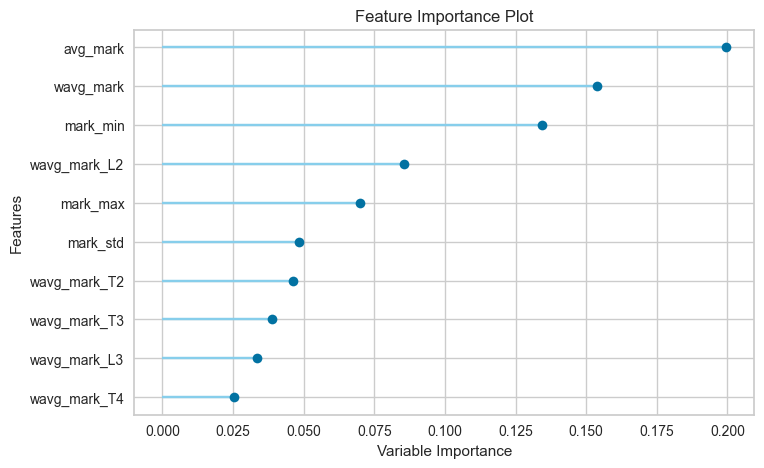

In [ ]:
import pandas as pd
import numpy as np
from pycaret.classification import *
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# LOAD Y2S2 DATA
file_path = r"C:\Users\User\Desktop\Final Year Project\22b6023 Muizzul\3 Processed Data\FeatureDatasetFixed_allSheets_Y4S2target_updated.xlsx"
sheet_name = "Y2S2"
target_col = "RISK_BAND_Y4S2"

df = pd.read_excel(file_path, sheet_name=sheet_name)


df_model = df[
    df[target_col].notna() &
    (df[target_col] != "dropped")
].copy()


df_model[target_col] = (
    df_model[target_col]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

print("Usable rows:", len(df_model))
print("\nTarget distribution:")
print(df_model[target_col].value_counts())


drop_cols = ["REGNO", "checkpoint_id", "checkpoint", "RISK_BAND", "RISK_BAND_Y4S2"]
feature_cols_to_drop = [c for c in drop_cols if c in df_model.columns]

model_df = df_model.drop(columns=feature_cols_to_drop, errors="ignore").copy()
model_df[target_col] = df_model[target_col]

model_df = model_df.dropna(axis=1, how="all")

# Remove duplicate columns if any
model_df = model_df.loc[:, ~model_df.columns.duplicated()]

print("\nFinal modelling shape:", model_df.shape)

# SETUP
exp = setup(
    data=model_df,
    target=target_col,
    session_id=42,
    fold=5,
    fold_strategy="stratifiedkfold",
    preprocess=True,
    normalize=True,
    fix_imbalance=False,
    remove_multicollinearity=False,
    verbose=False,
    html=False
)

# COMPARE STRONG MODELS 
candidate_models = ["rf", "et", "lightgbm", "gbc", "lr"]

best_model = compare_models(
    include=candidate_models,
    sort="F1",
    n_select=1,
    errors="ignore"
)

compare_df = pull().copy()
print("\nModel comparison:")
print(compare_df)

# TUNE BEST MODEL
tuned_model = tune_model(
    best_model,
    optimize="F1",
    choose_better=True
)

tune_df = pull().copy()
print("\nTuning results:")
print(tune_df)

final_model = finalize_model(tuned_model)

pred_holdout = predict_model(tuned_model)
holdout_df = pull().copy()

print("\nHoldout results:")
print(holdout_df)

pred_all = predict_model(final_model, data=model_df)

y_true = pred_all[target_col]
y_pred = pred_all["prediction_label"]

print("\nMacro F1 on full labelled data:")
print(f1_score(y_true, y_pred, average="macro"))

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))
=
print("\nTop Feature Importance:")
fi = plot_model(tuned_model, plot="feature")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# LOAD DATA
file_path = r"C:\Users\User\Desktop\Final Year Project\22b6023 Muizzul\3 Processed Data\FeatureDatasetFixed_allSheets_Y4S2target_updated.xlsx"
sheet_name = "Y2S2"
target_col = "RISK_BAND_Y4S2"

df = pd.read_excel(file_path, sheet_name=sheet_name)


df_model = df[
    df[target_col].notna() &
    (df[target_col] != "dropped")
].copy()

# Clean target text
df_model[target_col] = (
    df_model[target_col]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

drop_cols = [
    "REGNO",
    "checkpoint_idx",
    "checkpoint_sheet",
    "RISK_BAND",
    "RISK_BAND_Y4S2"
]

X = df_model.drop(columns=drop_cols, errors="ignore").copy()
y = df_model[target_col].copy()

# Keep only numeric columns jic
X = X.select_dtypes(include=[np.number]).copy()

print("X shape:", X.shape)
print("Feature columns:")
print(X.columns.tolist())

# TRAIN RANDOM FOREST
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X, y)

# FULL FEATURE IMPORTANCE
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nFull feature importance:")
print(importance_df)

output_path = r"C:\Users\User\Desktop\Final Year Project\22b6023 Muizzul\3 Processed Data\Y2S2_full_feature_importance.xlsx"
importance_df.to_excel(output_path, index=False)

print(f"\nSaved full feature importance table to:\n{output_path}")

X shape: (768, 27)
Feature columns:
['credits_attempted', 'module_count', 'wavg_mark', 'avg_mark', 'mark_min', 'mark_max', 'mark_std', 'fail_count', 'pass_count', 'credits_L1', 'credits_L2', 'credits_L3', 'credits_L4', 'wavg_mark_L1', 'wavg_mark_L2', 'wavg_mark_L3', 'wavg_mark_L4', 'credits_T1', 'credits_T2', 'credits_T3', 'credits_T4', 'credits_T5', 'wavg_mark_T1', 'wavg_mark_T2', 'wavg_mark_T3', 'wavg_mark_T4', 'wavg_mark_T5']

Full feature importance:
              Feature  Importance
3            avg_mark    0.146161
2           wavg_mark    0.131448
4            mark_min    0.105859
14       wavg_mark_L2    0.081583
5            mark_max    0.068860
6            mark_std    0.055126
23       wavg_mark_T2    0.047467
24       wavg_mark_T3    0.046830
25       wavg_mark_T4    0.035628
13       wavg_mark_L1    0.034384
15       wavg_mark_L3    0.033364
10         credits_L2    0.019239
26       wavg_mark_T5    0.018363
18         credits_T2    0.018328
16       wavg_mark_L4    0.0177

checking gpa vs marks vs both

In [ ]:
import pandas as pd
import numpy as np
from pycaret.classification import setup, compare_models, pull, models, predict_model

# CONFIG
file_path = r"C:\Users\User\Desktop\Final Year Project\22b6023 Muizzul\3 Processed Data\FeatureDatasetFixed_allSheets_Y4S2target_withGPA.xlsx"

history_sheets = ["Y1S1", "Y1S2", "Y2S1", "Y2S2"]
target_sheet = "Y2S2"
target_col = "RISK_BAND_Y4S2"

requested_models = ["lightgbm", "et", "rf", "gbc", "lr", "ada", "dt", "knn"]

marks_base_cols = [
    "wavg_mark", "avg_mark", "mark_min", "mark_max", "mark_std",
    "wavg_mark_L1", "wavg_mark_L2", "wavg_mark_L3", "wavg_mark_L4",
    "wavg_mark_T1", "wavg_mark_T2", "wavg_mark_T3", "wavg_mark_T4", "wavg_mark_T5"
]

# LOAD TARGET SHEET
target_df = pd.read_excel(file_path, sheet_name=target_sheet)

target_df = target_df[
    target_df[target_col].notna() &
    (target_df[target_col] != "dropped")
].copy()

target_df[target_col] = (
    target_df[target_col]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

master_df = target_df[["REGNO", target_col]].copy()

# MERGE MARKS Y + GPA  
for s in history_sheets:
    df_s = pd.read_excel(file_path, sheet_name=s).copy()

    keep_cols = ["REGNO"] + [c for c in marks_base_cols if c in df_s.columns]

    if "GPA" not in df_s.columns:
        raise ValueError(f"GPA column not found in sheet {s}")

    keep_cols.append("GPA")
    df_s = df_s[keep_cols].copy()

    rename_map = {}
    for c in df_s.columns:
        if c == "REGNO":
            continue
        elif c == "GPA":
            rename_map[c] = f"GPA_{s}"
        else:
            rename_map[c] = f"{c}_{s}"

    df_s = df_s.rename(columns=rename_map)

    master_df = master_df.merge(df_s, on="REGNO", how="left")

print("Master dataset shape:", master_df.shape)
print("\nTarget distribution:")
print(master_df[target_col].value_counts())
=
marks_history_features = []
for s in history_sheets:
    marks_history_features.extend([f"{c}_{s}" for c in marks_base_cols])

gpa_history_features = [f"GPA_{s}" for s in history_sheets]

combined_features = gpa_history_features + marks_history_features

feature_sets = {
    "Marks_history_only": marks_history_features,
    "GPA_history_only": gpa_history_features,
    "GPA_history_plus_Marks": combined_features
}
=
summary_rows = []

for set_name, feat_cols in feature_sets.items():
    print("\n" + "=" * 90)
    print(f"RUNNING FEATURE SET: {set_name}")
    print("=" * 90)

    feat_cols = [c for c in feat_cols if c in master_df.columns]

    temp = master_df[["REGNO", target_col] + feat_cols].copy()
    temp = temp.dropna()

    numeric_cols = temp.drop(columns=["REGNO", target_col]).select_dtypes(include=[np.number]).columns.tolist()
    model_df = temp[numeric_cols + [target_col]].copy()

    print("Rows used:", len(model_df))
    print("Predictor count:", len(numeric_cols))
    print("Target distribution:")
    print(model_df[target_col].value_counts())

    if len(model_df) < 30 or len(numeric_cols) == 0:
        summary_rows.append({
            "Feature_Set": set_name,
            "Rows_Used": len(model_df),
            "Predictor_Count": len(numeric_cols),
            "Best_Model": "Skipped",
            "CV_F1": np.nan,
            "Holdout_F1": np.nan,
            "Holdout_Accuracy": np.nan
        })
        continue

    exp = setup(
        data=model_df,
        target=target_col,
        session_id=42,
        fold=5,
        fold_strategy="stratifiedkfold",
        preprocess=True,
        normalize=True,
        remove_multicollinearity=False,
        fix_imbalance=False,
        verbose=False,
        html=False
    )

    available_model_ids = list(models().index)
    candidate_models = [m for m in requested_models if m in available_model_ids]

    best_model = compare_models(
        include=candidate_models,
        sort="F1",
        n_select=1,
        errors="ignore"
    )

    compare_df = pull().copy()
    print("\nModel comparison:")
    print(compare_df.head())

    best_model_name = compare_df.iloc[0]["Model"]
    best_cv_f1 = compare_df.iloc[0]["F1"]

    _ = predict_model(best_model)
    holdout_df = pull().copy()

    holdout_f1 = holdout_df.iloc[0]["F1"] if "F1" in holdout_df.columns else np.nan
    holdout_acc = holdout_df.iloc[0]["Accuracy"] if "Accuracy" in holdout_df.columns else np.nan

    summary_rows.append({
        "Feature_Set": set_name,
        "Rows_Used": len(model_df),
        "Predictor_Count": len(numeric_cols),
        "Best_Model": best_model_name,
        "CV_F1": best_cv_f1,
        "Holdout_F1": holdout_f1,
        "Holdout_Accuracy": holdout_acc
    })

summary_df = pd.DataFrame(summary_rows).sort_values("CV_F1", ascending=False).reset_index(drop=True)

print("\n" + "=" * 90)
print("FINAL COMPARISON: MARKS HISTORY vs GPA HISTORY vs COMBINED")
print("=" * 90)
print(summary_df)

output_path = r"C:\Users\User\Desktop\Final Year Project\22b6023 Muizzul\3 Processed Data\Y2S2_MarksHistory_vs_GPAHistory_vs_Combined.xlsx"
summary_df.to_excel(output_path, index=False)

print(f"\nSaved summary to:\n{output_path}")

Master dataset shape: (768, 62)

Target distribution:
RISK_BAND_Y4S2
Low Risk         335
Moderate Risk    293
High Risk        140
Name: count, dtype: int64

RUNNING FEATURE SET: Marks_history_only
Rows used: 542
Predictor count: 56
Target distribution:
RISK_BAND_Y4S2
Low Risk         268
Moderate Risk    198
High Risk         76
Name: count, dtype: int64


                                    Model  Accuracy     AUC  Recall   Prec.  \
et                 Extra Trees Classifier    0.8127  0.9253  0.8127  0.8176   
rf               Random Forest Classifier    0.8101  0.9230  0.8101  0.8140   
gbc          Gradient Boosting Classifier    0.7918  0.0000  0.7918  0.8026   
lightgbm  Light Gradient Boosting Machine    0.7678  0.9075  0.7678  0.7723   
ada                  Ada Boost Classifier    0.7572  0.0000  0.7572  0.7682   
lr                    Logistic Regression    0.7598  0.0000  0.7598  0.7630   
dt               Decision Tree Classifier    0.6966  0.7577  0.6966  0.7090   
knn                K Neighbors Classifier    0.6701  0.8260  0.6701  0.6796   

              F1   Kappa     MCC  TT (Sec)  
et        0.8099  0.6824  0.6853     0.828  
rf        0.8054  0.6761  0.6805     0.098  
gbc       0.7909  0.6495  0.6538     0.474  
lightgbm  0.7656  0.6098  0.6119     6.724  
ada       0.7577  0.5977  0.6025     0.072  
lr        0.7552  

                                    Model  Accuracy     AUC  Recall   Prec.  \
et                 Extra Trees Classifier    0.7903  0.9180  0.7903  0.7901   
knn                K Neighbors Classifier    0.7799  0.8916  0.7799  0.7847   
lr                    Logistic Regression    0.7721  0.0000  0.7721  0.7786   
rf               Random Forest Classifier    0.7697  0.9094  0.7697  0.7714   
gbc          Gradient Boosting Classifier    0.7644  0.0000  0.7644  0.7664   
lightgbm  Light Gradient Boosting Machine    0.7592  0.8995  0.7592  0.7631   
ada                  Ada Boost Classifier    0.7620  0.0000  0.7620  0.7613   
dt               Decision Tree Classifier    0.6762  0.7366  0.6762  0.6761   

              F1   Kappa     MCC  TT (Sec)  
et        0.7873  0.6473  0.6494     0.078  
knn       0.7788  0.6296  0.6312     0.028  
lr        0.7697  0.6148  0.6186     0.016  
rf        0.7673  0.6137  0.6161     0.092  
gbc       0.7615  0.6078  0.6110     0.136  
lightgbm  0.7578  

                                    Model  Accuracy     AUC  Recall   Prec.  \
rf               Random Forest Classifier    0.8364  0.9246  0.8364  0.8403   
et                 Extra Trees Classifier    0.8048  0.9222  0.8048  0.8083   
lightgbm  Light Gradient Boosting Machine    0.7942  0.9145  0.7942  0.7978   
gbc          Gradient Boosting Classifier    0.7890  0.0000  0.7890  0.7985   
ada                  Ada Boost Classifier    0.7596  0.0000  0.7596  0.7762   
lr                    Logistic Regression    0.7625  0.0000  0.7625  0.7710   
dt               Decision Tree Classifier    0.7019  0.7585  0.7019  0.7084   
knn                K Neighbors Classifier    0.7044  0.8479  0.7044  0.7131   

              F1   Kappa     MCC  TT (Sec)  
rf        0.8337  0.7216  0.7249     0.098  
et        0.8022  0.6689  0.6712     0.090  
lightgbm  0.7922  0.6534  0.6554     0.294  
gbc       0.7833  0.6417  0.6474     0.530  
ada       0.7608  0.6004  0.6062     0.090  
lr        0.7575  

tune vs base

In [ ]:
import pandas as pd
import numpy as np
from pycaret.classification import setup, create_model, tune_model, predict_model, pull, finalize_model

file_path = r"C:\Users\User\Desktop\Final Year Project\22b6023 Muizzul\3 Processed Data\FeatureDatasetFixed_allSheets_Y4S2target_withGPA.xlsx"

history_sheets = ["Y1S1", "Y1S2", "Y2S1", "Y2S2"]
target_sheet = "Y2S2"
target_col = "RISK_BAND_Y4S2"

marks_base_cols = [
    "wavg_mark", "avg_mark", "mark_min", "mark_max", "mark_std",
    "wavg_mark_L1", "wavg_mark_L2", "wavg_mark_L3", "wavg_mark_L4",
    "wavg_mark_T1", "wavg_mark_T2", "wavg_mark_T3", "wavg_mark_T4", "wavg_mark_T5"
]

target_df = pd.read_excel(file_path, sheet_name=target_sheet)

target_df = target_df[
    target_df[target_col].notna() &
    (target_df[target_col] != "dropped")
].copy()

target_df[target_col] = (
    target_df[target_col]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

master_df = target_df[["REGNO", target_col]].copy()

for s in history_sheets:
    df_s = pd.read_excel(file_path, sheet_name=s).copy()

    keep_cols = ["REGNO"] + [c for c in marks_base_cols if c in df_s.columns] + ["GPA"]
    df_s = df_s[keep_cols].copy()

    rename_map = {}
    for c in df_s.columns:
        if c == "REGNO":
            continue
        elif c == "GPA":
            rename_map[c] = f"GPA_{s}"
        else:
            rename_map[c] = f"{c}_{s}"

    df_s = df_s.rename(columns=rename_map)
    master_df = master_df.merge(df_s, on="REGNO", how="left")

marks_history_features = []
for s in history_sheets:
    marks_history_features.extend([f"{c}_{s}" for c in marks_base_cols])

gpa_history_features = [f"GPA_{s}" for s in history_sheets]

combined_features = gpa_history_features + marks_history_features

temp = master_df[["REGNO", target_col] + combined_features].copy()
temp = temp.dropna()

numeric_cols = temp.drop(columns=["REGNO", target_col]).select_dtypes(include=[np.number]).columns.tolist()
model_df = temp[numeric_cols + [target_col]].copy()

print("Rows used:", len(model_df))
print("Predictor count:", len(numeric_cols))
print(model_df[target_col].value_counts())


# PYCARET SETUP
exp = setup(
    data=model_df,
    target=target_col,
    session_id=42,
    fold=5,
    fold_strategy="stratifiedkfold",
    preprocess=True,
    normalize=True,
    remove_multicollinearity=False,
    fix_imbalance=False,
    verbose=False,
    html=False
)

# BASE RANDOM FOREST
base_rf = create_model("rf")
base_cv_df = pull().copy()

print("\nBase Random Forest CV results:")
print(base_cv_df)

base_cv_f1 = base_cv_df.loc["Mean", "F1"] if "Mean" in base_cv_df.index else np.nan

_ = predict_model(base_rf)
base_holdout_df = pull().copy()

print("\nBase Random Forest holdout results:")
print(base_holdout_df)

base_holdout_f1 = base_holdout_df.iloc[0]["F1"] if "F1" in base_holdout_df.columns else np.nan
base_holdout_acc = base_holdout_df.iloc[0]["Accuracy"] if "Accuracy" in base_holdout_df.columns else np.nan

# TUNED RANDOM FOREST
tuned_rf = tune_model(
    base_rf,
    optimize="F1",
    choose_better=True
)
tuned_cv_df = pull().copy()

print("\nTuned Random Forest CV results:")
print(tuned_cv_df)

tuned_cv_f1 = tuned_cv_df.loc["Mean", "F1"] if "Mean" in tuned_cv_df.index else np.nan

_ = predict_model(tuned_rf)
tuned_holdout_df = pull().copy()

print("\nTuned Random Forest holdout results:")
print(tuned_holdout_df)

tuned_holdout_f1 = tuned_holdout_df.iloc[0]["F1"] if "F1" in tuned_holdout_df.columns else np.nan
tuned_holdout_acc = tuned_holdout_df.iloc[0]["Accuracy"] if "Accuracy" in tuned_holdout_df.columns else np.nan

comparison_df = pd.DataFrame([
    {
        "Model_Version": "Base Random Forest",
        "CV_F1": base_cv_f1,
        "Holdout_F1": base_holdout_f1,
        "Holdout_Accuracy": base_holdout_acc
    },
    {
        "Model_Version": "Tuned Random Forest",
        "CV_F1": tuned_cv_f1,
        "Holdout_F1": tuned_holdout_f1,
        "Holdout_Accuracy": tuned_holdout_acc
    }
])

print("\n" + "=" * 80)
print("BASE VS TUNED RANDOM FOREST")
print("=" * 80)
print(comparison_df)

output_path = r"C:\Users\User\Desktop\Final Year Project\22b6023 Muizzul\3 Processed Data\Y2S2_GPAandMarks_RF_base_vs_tuned.xlsx"
comparison_df.to_excel(output_path, index=False)

print(f"\nSaved comparison to:\n{output_path}")
print("\nTuned model details:")
print(tuned_rf)

Rows used: 542
Predictor count: 60
RISK_BAND_Y4S2
Low Risk         268
Moderate Risk    198
High Risk         76
Name: count, dtype: int64


      Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                          
0       0.7632  0.8958  0.7632  0.7624  0.7547  0.5875  0.5932
1       0.9079  0.9469  0.9079  0.9085  0.9078  0.8465  0.8468
2       0.8684  0.9503  0.8684  0.8755  0.8691  0.7820  0.7847
3       0.8026  0.9176  0.8026  0.8162  0.8028  0.6672  0.6699
4       0.8400  0.9126  0.8400  0.8387  0.8341  0.7250  0.7297
Mean    0.8364  0.9246  0.8364  0.8403  0.8337  0.7216  0.7249
Std     0.0503  0.0209  0.0503  0.0501  0.0528  0.0897  0.0881

Base Random Forest CV results:
      Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                          
0       0.7632  0.8958  0.7632  0.7624  0.7547  0.5875  0.5932
1       0.9079  0.9469  0.9079  0.9085  0.9078  0.8465  0.8468
2       0.8684  0.9503  0.8684  0.8755  0.8691  0.7820  0.7847
3       0.8026  0.9176  0.8026  0.8162  0.8028  0.6672  0.6699
4       0.8400  0.9126 

Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
      Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                          
0       0.7368  0.8956  0.7368  0.7380  0.7282  0.5402  0.5472
1       0.8553  0.9564  0.8553  0.8541  0.8544  0.7588  0.7590
2       0.8553  0.9557  0.8553  0.8602  0.8557  0.7596  0.7611
3       0.8026  0.9052  0.8026  0.8162  0.8028  0.6672  0.6699
4       0.8533  0.9282  0.8533  0.8626  0.8456  0.7458  0.7515
Mean    0.8207  0.9282  0.8207  0.8262  0.8173  0.6943  0.6977
Std     0.0465  0.0251  0.0465  0.0472  0.0486  0.0843  0.0826

Tuned Random Forest CV results:
      Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                          
0       0.7368  0.8956  0.7368  0.7380  0.7282  0.5402  0.5472
1       0.8553  0.9564  0.8553  0.8541  0.8544  0.7588  0.7590

checkign the feature imporatnce 


Rows used: 542
Predictor count: 60

Target distribution:
RISK_BAND_Y4S2
Low Risk         268
Moderate Risk    198
High Risk         76
Name: count, dtype: int64

Top 20 Feature Importances:
              Feature  Importance
47      avg_mark_Y2S2    0.070992
46     wavg_mark_Y2S2    0.067031
3            GPA_Y2S2    0.061171
48      mark_min_Y2S2    0.053443
32     wavg_mark_Y2S1    0.043473
2            GPA_Y2S1    0.043008
33      avg_mark_Y2S1    0.042847
0            GPA_Y1S1    0.040771
19      avg_mark_Y1S2    0.033138
5       avg_mark_Y1S1    0.032995
1            GPA_Y1S2    0.032926
18     wavg_mark_Y1S2    0.030625
34      mark_min_Y2S1    0.027497
52  wavg_mark_L2_Y2S2    0.024675
4      wavg_mark_Y1S1    0.022241
6       mark_min_Y1S1    0.019991
21      mark_max_Y1S2    0.017779
50      mark_std_Y2S2    0.017588
35      mark_max_Y2S1    0.015090
23  wavg_mark_L1_Y1S2    0.014202

Feature importance saved to:
C:\Users\User\Desktop\Final Year Project\22b6023 Muizzul\3 Process

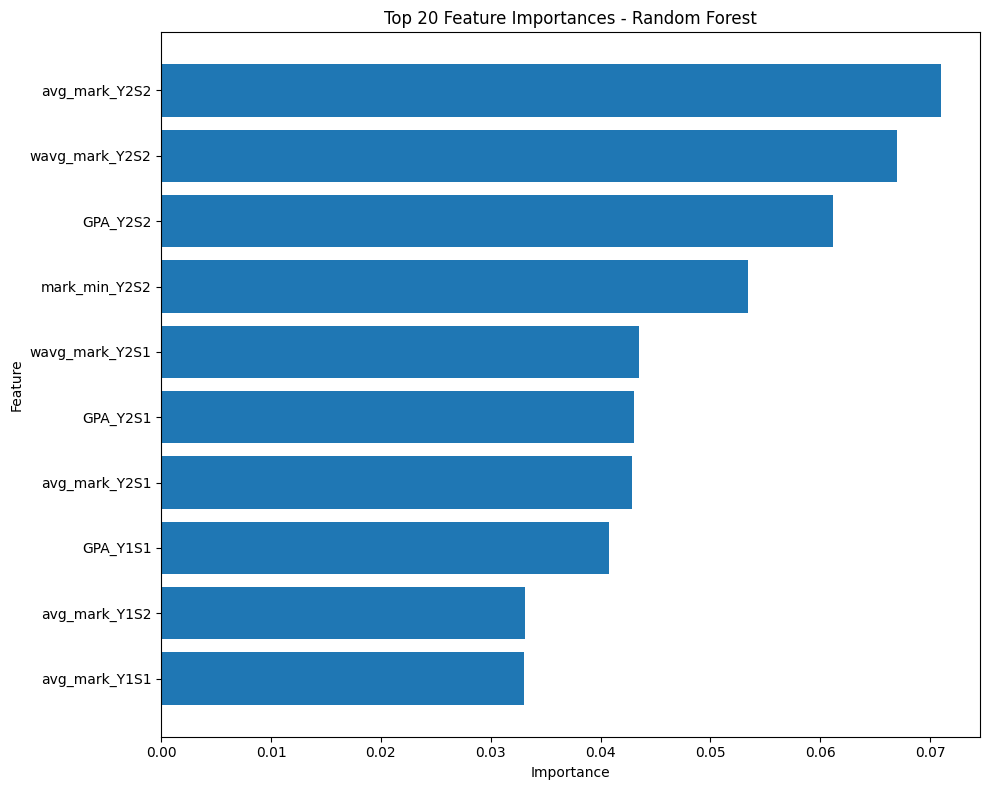


Confusion Matrix:
                      Pred_High Risk  Pred_Moderate Risk  Pred_Low Risk
Actual_High Risk                   9                   6              0
Actual_Moderate Risk               5                  32              3
Actual_Low Risk                    0                   5             49


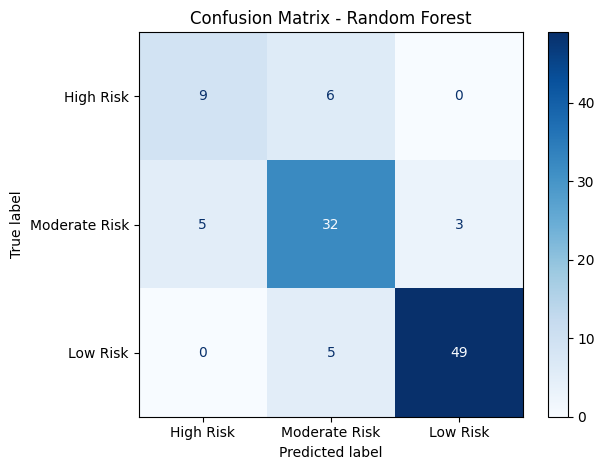


Classification Report:
               precision    recall  f1-score   support

    High Risk       0.64      0.60      0.62        15
Moderate Risk       0.74      0.80      0.77        40
     Low Risk       0.94      0.91      0.92        54

     accuracy                           0.83       109
    macro avg       0.78      0.77      0.77       109
 weighted avg       0.83      0.83      0.83       109

Model saved to: C:\Users\User\Desktop\Final Year Project\22b6023 Muizzul\3 Processed Data\base_random_forest_Y2S2.pkl
Feature list saved to: C:\Users\User\Desktop\Final Year Project\22b6023 Muizzul\3 Processed Data\base_random_forest_Y2S2_features.pkl


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# CONFIG
file_path = r"C:\Users\User\Desktop\Final Year Project\22b6023 Muizzul\3 Processed Data\MARKS GPA.xlsx"

history_sheets = ["Y1S1", "Y1S2", "Y2S1", "Y2S2"]
target_sheet = "Y2S2"
target_col = "RISK_BAND_Y4S2"

marks_base_cols = [
    "wavg_mark", "avg_mark", "mark_min", "mark_max", "mark_std",
    "wavg_mark_L1", "wavg_mark_L2", "wavg_mark_L3", "wavg_mark_L4",
    "wavg_mark_T1", "wavg_mark_T2", "wavg_mark_T3", "wavg_mark_T4", "wavg_mark_T5"
]

target_df = pd.read_excel(file_path, sheet_name=target_sheet)

target_df = target_df[
    target_df[target_col].notna() &
    (target_df[target_col] != "dropped")
].copy()

target_df[target_col] = (
    target_df[target_col]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

master_df = target_df[["REGNO", target_col]].copy()


# MERGE GPA MARKS FROM Y1S1 TO Y2S2
for s in history_sheets:
    df_s = pd.read_excel(file_path, sheet_name=s).copy()

    keep_cols = ["REGNO"] + [c for c in marks_base_cols if c in df_s.columns] + ["GPA"]
    df_s = df_s[keep_cols].copy()

    rename_map = {}
    for c in df_s.columns:
        if c == "REGNO":
            continue
        elif c == "GPA":
            rename_map[c] = f"GPA_{s}"
        else:
            rename_map[c] = f"{c}_{s}"

    df_s = df_s.rename(columns=rename_map)
    master_df = master_df.merge(df_s, on="REGNO", how="left")

# GPA HISTORY + MARKS HISTORY
marks_history_features = []
for s in history_sheets:
    marks_history_features.extend([f"{c}_{s}" for c in marks_base_cols])

gpa_history_features = [f"GPA_{s}" for s in history_sheets]

combined_features = gpa_history_features + marks_history_features

temp = master_df[["REGNO", target_col] + combined_features].copy()
temp = temp.dropna()

X = temp.drop(columns=["REGNO", target_col]).copy()
X = X.select_dtypes(include=[np.number]).copy()
y = temp[target_col].copy()

print("Rows used:", len(X))
print("Predictor count:", X.shape[1])
print("\nTarget distribution:")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
# BASE RANDOM FOREST MODEL
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nTop 20 Feature Importances:")
print(importance_df.head(20))

importance_output = r"C:\Users\User\Desktop\Final Year Project\22b6023 Muizzul\3 Processed Data\Y2S2_RF_feature_importance.xlsx"
importance_df.to_excel(importance_output, index=False)
print(f"\nFeature importance saved to:\n{importance_output}")

# Optional: plot top 10 features
top_n = 10
plt.figure(figsize=(10, 8))
plt.barh(
    importance_df["Feature"].head(top_n)[::-1],
    importance_df["Importance"].head(top_n)[::-1]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

# CONFUSION MATRIX
y_pred = rf.predict(X_test)

labels = ["High Risk", "Moderate Risk", "Low Risk"]
cm = confusion_matrix(y_test, y_pred, labels=labels)

print("\nConfusion Matrix:")
print(pd.DataFrame(cm, index=[f"Actual_{l}" for l in labels], columns=[f"Pred_{l}" for l in labels]))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, labels=labels))

import joblib

model_output = r"C:\Users\User\Desktop\Final Year Project\22b6023 Muizzul\3 Processed Data\base_random_forest_Y2S2.pkl"
features_output = r"C:\Users\User\Desktop\Final Year Project\22b6023 Muizzul\3 Processed Data\base_random_forest_Y2S2_features.pkl"

joblib.dump(rf, model_output)
joblib.dump(list(X.columns), features_output)

print("Model saved to:", model_output)
print("Feature list saved to:", features_output)

In [4]:
import joblib

features = joblib.load(r"C:\Users\User\Desktop\Final Year Project\22b6023 Muizzul\3 Processed Data\base_random_forest_Y2S2_features.pkl")

for i, f in enumerate(features, 1):
    print(f"{i}. {f}")

print("\nTotal features:", len(features))

1. GPA_Y1S1
2. GPA_Y1S2
3. GPA_Y2S1
4. GPA_Y2S2
5. wavg_mark_Y1S1
6. avg_mark_Y1S1
7. mark_min_Y1S1
8. mark_max_Y1S1
9. mark_std_Y1S1
10. wavg_mark_L1_Y1S1
11. wavg_mark_L2_Y1S1
12. wavg_mark_L3_Y1S1
13. wavg_mark_L4_Y1S1
14. wavg_mark_T1_Y1S1
15. wavg_mark_T2_Y1S1
16. wavg_mark_T3_Y1S1
17. wavg_mark_T4_Y1S1
18. wavg_mark_T5_Y1S1
19. wavg_mark_Y1S2
20. avg_mark_Y1S2
21. mark_min_Y1S2
22. mark_max_Y1S2
23. mark_std_Y1S2
24. wavg_mark_L1_Y1S2
25. wavg_mark_L2_Y1S2
26. wavg_mark_L3_Y1S2
27. wavg_mark_L4_Y1S2
28. wavg_mark_T1_Y1S2
29. wavg_mark_T2_Y1S2
30. wavg_mark_T3_Y1S2
31. wavg_mark_T4_Y1S2
32. wavg_mark_T5_Y1S2
33. wavg_mark_Y2S1
34. avg_mark_Y2S1
35. mark_min_Y2S1
36. mark_max_Y2S1
37. mark_std_Y2S1
38. wavg_mark_L1_Y2S1
39. wavg_mark_L2_Y2S1
40. wavg_mark_L3_Y2S1
41. wavg_mark_L4_Y2S1
42. wavg_mark_T1_Y2S1
43. wavg_mark_T2_Y2S1
44. wavg_mark_T3_Y2S1
45. wavg_mark_T4_Y2S1
46. wavg_mark_T5_Y2S1
47. wavg_mark_Y2S2
48. avg_mark_Y2S2
49. mark_min_Y2S2
50. mark_max_Y2S2
51. mark_std_Y2S2

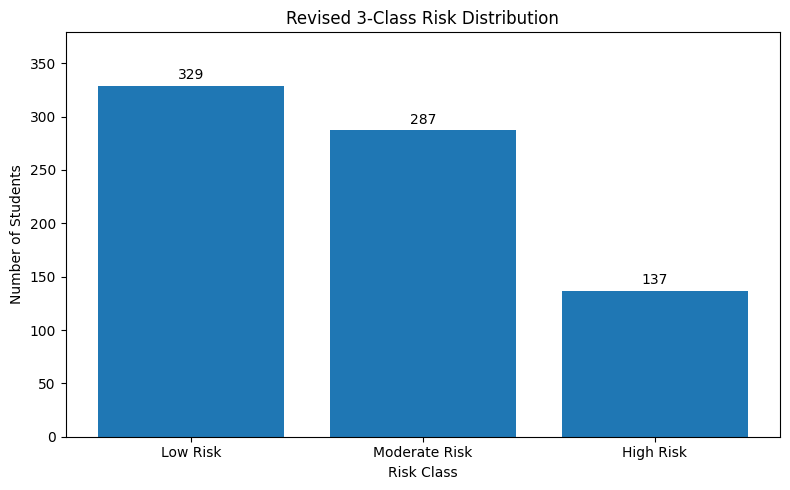

In [1]:
import matplotlib.pyplot as plt

# Revised 3-class distribution
classes = ["Low Risk", "Moderate Risk", "High Risk"]
counts = [329, 287, 137]

plt.figure(figsize=(8, 5))
bars = plt.bar(classes, counts)

# Add value labels on top of bars
for bar, count in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        str(count),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Revised 3-Class Risk Distribution")
plt.xlabel("Risk Class")
plt.ylabel("Number of Students")
plt.ylim(0, max(counts) + 50)
plt.tight_layout()
plt.show()

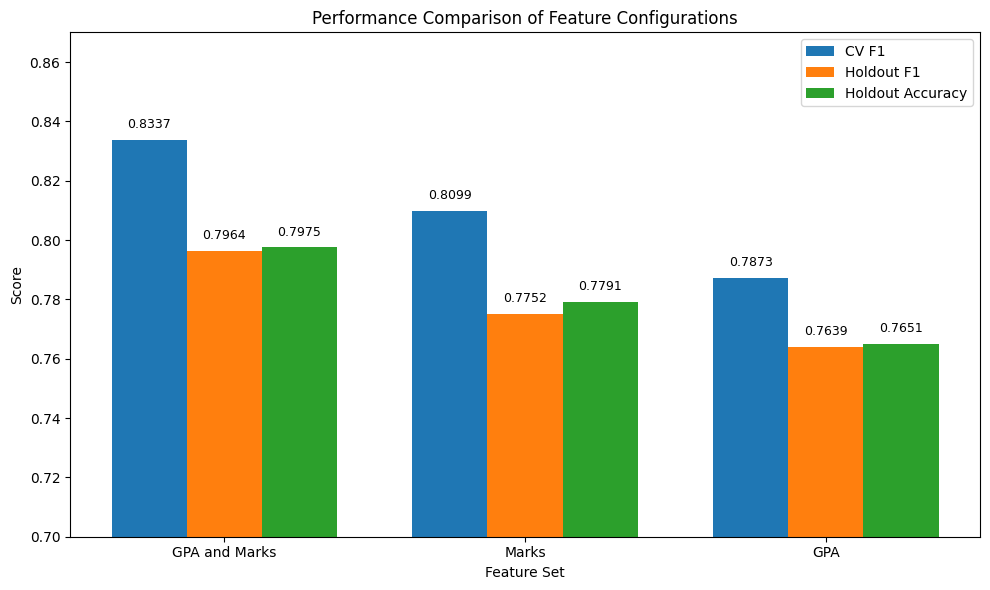

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Data
feature_sets = ["GPA and Marks", "Marks", "GPA"]
cv_f1 = [0.8337, 0.8099, 0.7873]
holdout_f1 = [0.7964, 0.7752, 0.7639]
holdout_accuracy = [0.7975, 0.7791, 0.7651]

x = np.arange(len(feature_sets))
width = 0.25

plt.figure(figsize=(10, 6))

bars1 = plt.bar(x - width, cv_f1, width, label="CV F1")
bars2 = plt.bar(x, holdout_f1, width, label="Holdout F1")
bars3 = plt.bar(x + width, holdout_accuracy, width, label="Holdout Accuracy")

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.003,
            f"{height:.4f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.xticks(x, feature_sets)
plt.ylabel("Score")
plt.xlabel("Feature Set")
plt.title("Performance Comparison of Feature Configurations")
plt.ylim(0.70, 0.87)
plt.legend()
plt.tight_layout()
plt.show()

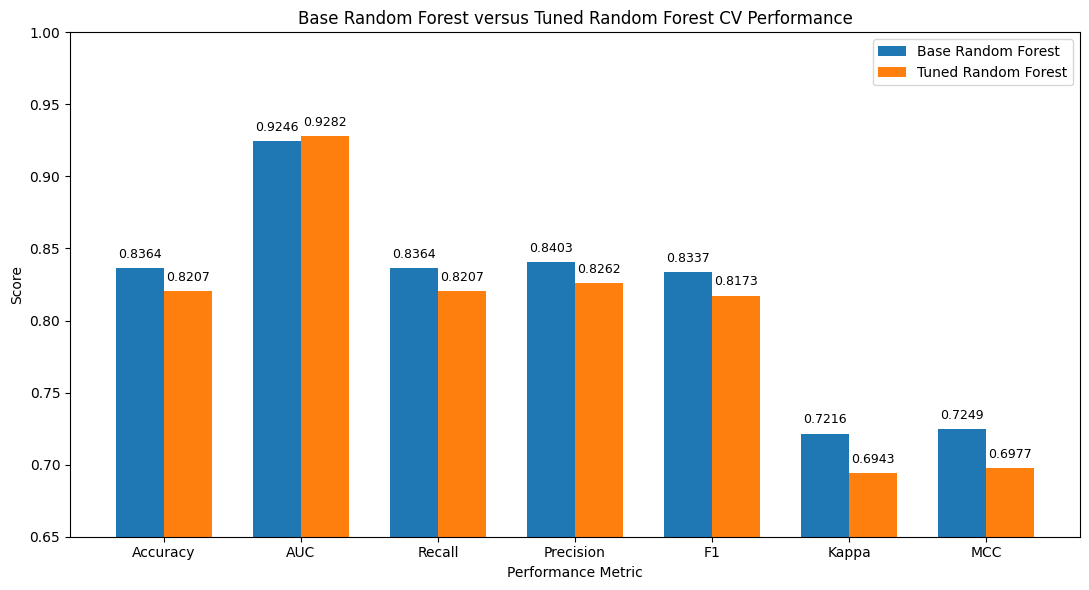

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics
metrics = ["Accuracy", "AUC", "Recall", "Precision", "F1", "Kappa", "MCC"]

# Base Random Forest CV mean results
base_scores = [0.8364, 0.9246, 0.8364, 0.8403, 0.8337, 0.7216, 0.7249]

# Tuned Random Forest CV mean results
tuned_scores = [0.8207, 0.9282, 0.8207, 0.8262, 0.8173, 0.6943, 0.6977]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(11, 6))

bars1 = plt.bar(x - width/2, base_scores, width, label="Base Random Forest")
bars2 = plt.bar(x + width/2, tuned_scores, width, label="Tuned Random Forest")

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.005,
            f"{height:.4f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.xlabel("Performance Metric")
plt.title("Base Random Forest versus Tuned Random Forest CV Performance")
plt.ylim(0.65, 1.00)
plt.legend()
plt.tight_layout()
plt.show()